# Temporal XAS Analysis: xcs101591326

Fluorescence-detected XAS with time-delay binning (lxt_fast via enc/lasDelay).  
Run 91: 1 ps bins from -40 to 100 ps at fixed DCCM energy 7126.5 eV.  
Signal: mu = If/I0 (epix_2/ROI_sum / ipm5/sum) vs time delay.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')
from XSpect.controller.pipeline import Pipeline

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Run the Pipeline

In [2]:
pipeline = Pipeline.from_yaml("examples/xcs101591326_temporal_xas.yaml")
pipeline.run(cores=4, batch_size=2000)

print(f"Analyzed {len(pipeline.analyzed_runs)} run(s)")
print(f"Result keys: {sorted(pipeline.results.keys())}")

Analyzed 7 run(s)
Result keys: ['delays', 'difference', 'encoder', 'epix', 'epix_simultaneous_laser', 'epix_simultaneous_laser_bincount', 'epix_simultaneous_laser_time_binned', 'epix_xray_not_laser', 'epix_xray_not_laser_bincount', 'epix_xray_not_laser_time_binned', 'ipm', 'ipm_simultaneous_laser', 'ipm_simultaneous_laser_bincount', 'ipm_simultaneous_laser_time_binned', 'ipm_xray_not_laser', 'ipm_xray_not_laser_bincount', 'ipm_xray_not_laser_time_binned', 'laser_off_average', 'laser_off_count', 'laser_off_summed', 'laser_on_average', 'laser_on_count', 'laser_on_summed', 'time_bins', 'time_bins_centered', 'timing_bin_indices', 'timing_bin_indices_simultaneous_laser', 'timing_bin_indices_xray_not_laser']


## 2. Extract Results

The pipeline produces time-binned I0 (ipm) and If (epix) for laser-on and laser-off shots.  
The `combine_runs` reduction computes averages and the normalized difference.

In [3]:
results = pipeline.results
run = pipeline.analyzed_runs[0]

# Time axis
time_bins = getattr(run, 'time_bins', None)
if time_bins is None:
    time_bins = np.linspace(-10, 25, 35)
    print("Warning: time_bins not found on run, using nominal values")

print(f"Time bins: {len(time_bins)} points, range [{time_bins[0]:.1f}, {time_bins[-1]:.1f}] ps")

Time bins: 35 points, range [-10.0, 25.0] ps


In [4]:
# Per-run time-binned data (from run attributes)
ipm_on = getattr(run, 'ipm_simultaneous_laser_time_binned', None)
ipm_off = getattr(run, 'ipm_xray_not_laser_time_binned', None)
epix_on = getattr(run, 'epix_simultaneous_laser_time_binned', None)
epix_off = getattr(run, 'epix_xray_not_laser_time_binned', None)

ipm_on_count = getattr(run, 'ipm_simultaneous_laser_bincount', None)
ipm_off_count = getattr(run, 'ipm_xray_not_laser_bincount', None)

print(f"IPM laser-on shape: {ipm_on.shape if ipm_on is not None else 'N/A'}")
print(f"IPM laser-off shape: {ipm_off.shape if ipm_off is not None else 'N/A'}")
print(f"Epix laser-on shape: {epix_on.shape if epix_on is not None else 'N/A'}")
print(f"Epix laser-off shape: {epix_off.shape if epix_off is not None else 'N/A'}")

IPM laser-on shape: (35,)
IPM laser-off shape: (35,)
Epix laser-on shape: (35,)
Epix laser-off shape: (35,)


## 3. Compute XAS Signal: mu = If / I0

In [5]:
# Compute average per time bin
def safe_average(summed, counts):
    """Compute average, masking bins with zero counts."""
    safe = np.where(counts > 0, counts, np.nan)
    return summed / safe

# Average I0 and If per time bin
avg_ipm_on = safe_average(ipm_on, ipm_on_count)
avg_ipm_off = safe_average(ipm_off, ipm_off_count)
avg_epix_on = safe_average(epix_on, ipm_on_count)
avg_epix_off = safe_average(epix_off, ipm_off_count)

# XAS signal: mu = If/I0
mu_on = avg_epix_on / avg_ipm_on
mu_off = avg_epix_off / avg_ipm_off

print(f"mu_on range: [{np.nanmin(mu_on):.4f}, {np.nanmax(mu_on):.4f}]")
print(f"mu_off range: [{np.nanmin(mu_off):.4f}, {np.nanmax(mu_off):.4f}]")

mu_on range: [0.0009, 0.0011]
mu_off range: [0.0009, 0.0012]


## 4. Plot XAS Transient: Laser-On vs Laser-Off

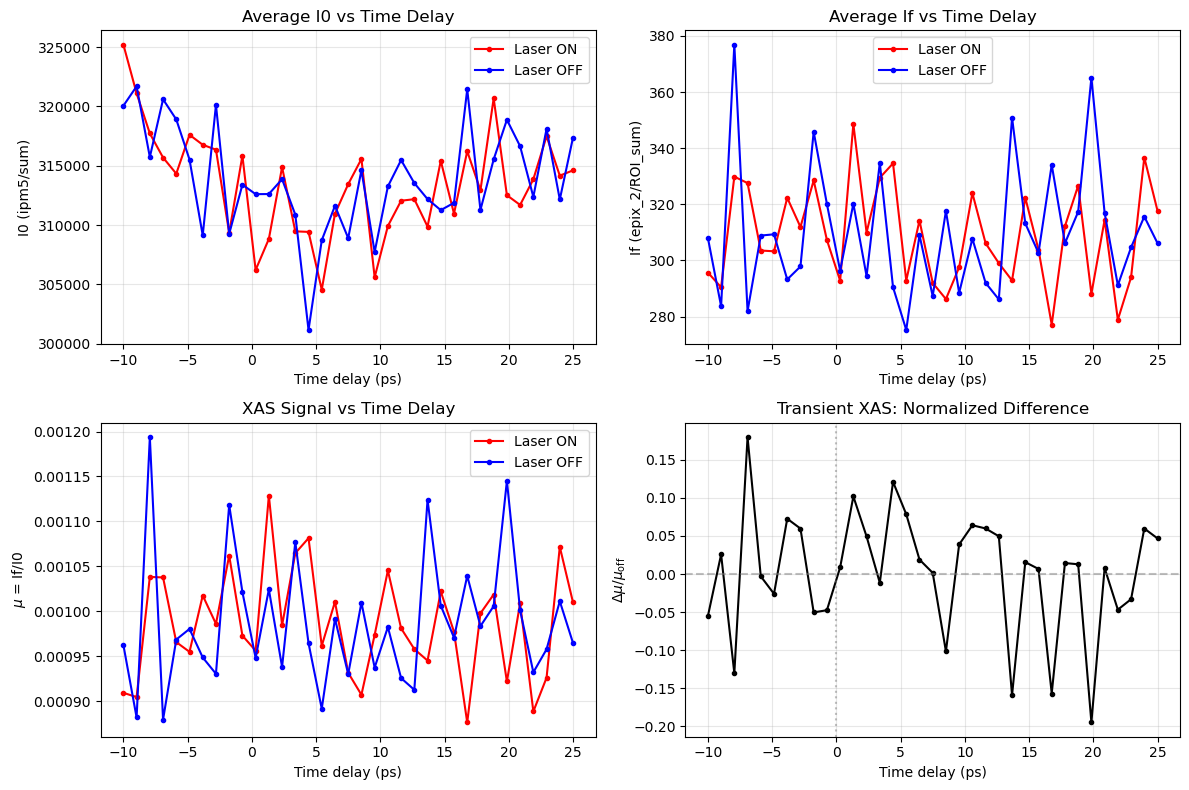

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top left: Raw I0 (ipm) vs time
ax = axes[0, 0]
ax.plot(time_bins, avg_ipm_on, 'r.-', label='Laser ON')
ax.plot(time_bins, avg_ipm_off, 'b.-', label='Laser OFF')
ax.set_xlabel('Time delay (ps)')
ax.set_ylabel('I0 (ipm5/sum)')
ax.set_title('Average I0 vs Time Delay')
ax.legend()
ax.grid(True, alpha=0.3)

# Top right: Raw If (epix) vs time
ax = axes[0, 1]
ax.plot(time_bins, avg_epix_on, 'r.-', label='Laser ON')
ax.plot(time_bins, avg_epix_off, 'b.-', label='Laser OFF')
ax.set_xlabel('Time delay (ps)')
ax.set_ylabel('If (epix_2/ROI_sum)')
ax.set_title('Average If vs Time Delay')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom left: mu = If/I0 vs time
ax = axes[1, 0]
ax.plot(time_bins, mu_on, 'r.-', label='Laser ON')
ax.plot(time_bins, mu_off, 'b.-', label='Laser OFF')
ax.set_xlabel('Time delay (ps)')
ax.set_ylabel(r'$\mu$ = If/I0')
ax.set_title('XAS Signal vs Time Delay')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom right: Normalized difference
ax = axes[1, 1]
delta_mu = (mu_on - mu_off) / mu_off
ax.plot(time_bins, delta_mu, 'k.-', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time delay (ps)')
ax.set_ylabel(r'$\Delta\mu / \mu_\mathrm{off}$')
ax.set_title('Transient XAS: Normalized Difference')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Shot Statistics

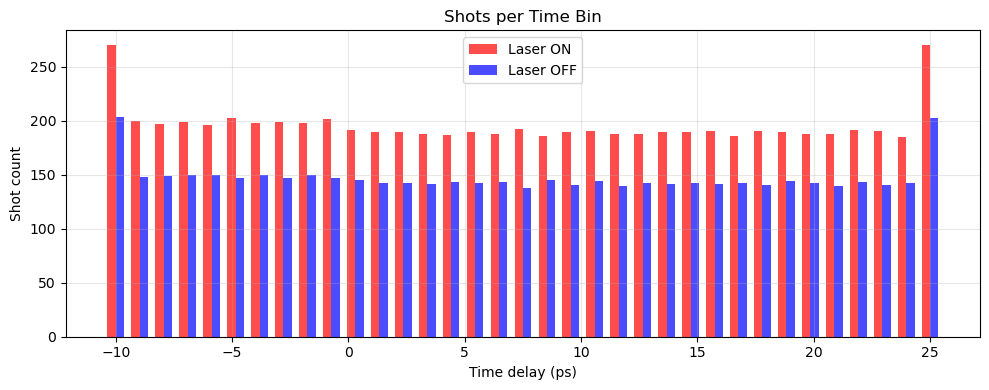

Total laser-on shots: 6859
Total laser-off shots: 5145


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

width = (time_bins[1] - time_bins[0]) * 0.35 if len(time_bins) > 1 else 1.0
ax.bar(time_bins - width/2, ipm_on_count, width=width, alpha=0.7, label='Laser ON', color='red')
ax.bar(time_bins + width/2, ipm_off_count, width=width, alpha=0.7, label='Laser OFF', color='blue')
ax.set_xlabel('Time delay (ps)')
ax.set_ylabel('Shot count')
ax.set_title('Shots per Time Bin')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total laser-on shots: {int(np.nansum(ipm_on_count))}")
print(f"Total laser-off shots: {int(np.nansum(ipm_off_count))}")

## 6. Reduction Results (combine_runs)

If multiple runs were combined, the reduction step provides summed/averaged results.

Reduction result keys: ['delays', 'difference', 'encoder', 'epix', 'epix_simultaneous_laser', 'epix_simultaneous_laser_bincount', 'epix_simultaneous_laser_time_binned', 'epix_xray_not_laser', 'epix_xray_not_laser_bincount', 'epix_xray_not_laser_time_binned', 'ipm', 'ipm_simultaneous_laser', 'ipm_simultaneous_laser_bincount', 'ipm_simultaneous_laser_time_binned', 'ipm_xray_not_laser', 'ipm_xray_not_laser_bincount', 'ipm_xray_not_laser_time_binned', 'laser_off_average', 'laser_off_count', 'laser_off_summed', 'laser_on_average', 'laser_on_count', 'laser_on_summed', 'time_bins', 'time_bins_centered', 'timing_bin_indices', 'timing_bin_indices_simultaneous_laser', 'timing_bin_indices_xray_not_laser']


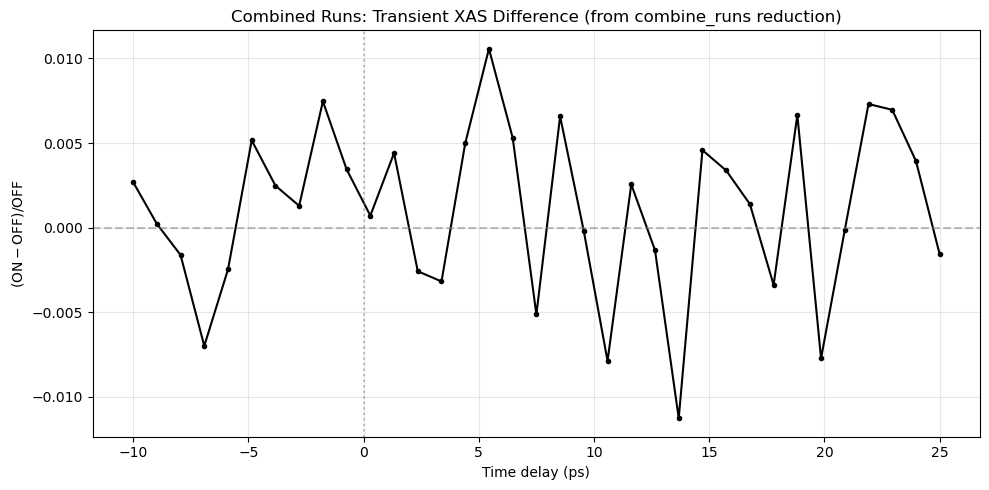

In [8]:
# Check reduction results
reduction_keys = [k for k in results.keys() if not k.startswith('run_')]
print(f"Reduction result keys: {sorted(reduction_keys)}")

if 'difference' in results and results['difference'] is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    diff = results['difference']
    ax.plot(time_bins, diff, 'k.-', linewidth=1.5)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time delay (ps)')
    ax.set_ylabel(r'$(\mathrm{ON} - \mathrm{OFF}) / \mathrm{OFF}$')
    ax.set_title('Combined Runs: Transient XAS Difference (from combine_runs reduction)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No combined difference result (single run or reduction not applicable).")

## 7. Transient XAS Kinetics (selected time ranges)

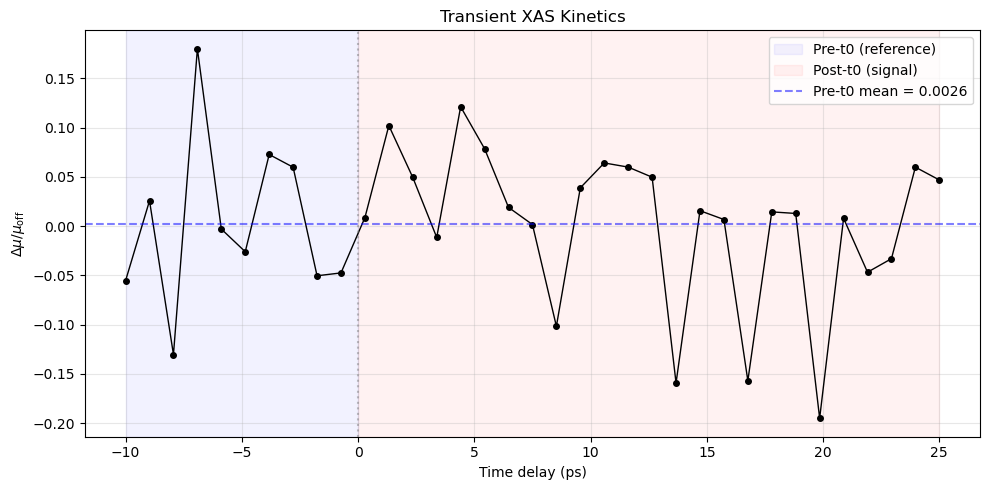

Pre-t0 baseline: 0.002562
Max |signal| post-t0: 0.195019
Signal/noise estimate: 2.4


In [9]:
# Plot kinetics: delta_mu integrated over different time windows
fig, ax = plt.subplots(figsize=(10, 5))

# Identify pre-time-zero (reference) and post-time-zero (signal)
pre_mask = time_bins < 0
post_mask = time_bins >= 0

# Plot the full transient
ax.plot(time_bins, delta_mu, 'ko-', markersize=4, linewidth=1)

# Shade pre-t0 and post-t0 regions
ax.axvspan(time_bins[pre_mask][0], 0, alpha=0.05, color='blue', label='Pre-t0 (reference)')
ax.axvspan(0, time_bins[post_mask][-1], alpha=0.05, color='red', label='Post-t0 (signal)')

# Reference level from pre-t0
pre_t0_mean = np.nanmean(delta_mu[pre_mask])
ax.axhline(pre_t0_mean, color='blue', linestyle='--', alpha=0.5, 
           label=f'Pre-t0 mean = {pre_t0_mean:.4f}')
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('Time delay (ps)')
ax.set_ylabel(r'$\Delta\mu / \mu_\mathrm{off}$')
ax.set_title('Transient XAS Kinetics')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report signal amplitude
post_t0_max = np.nanmax(np.abs(delta_mu[post_mask]))
print(f"Pre-t0 baseline: {pre_t0_mean:.6f}")
print(f"Max |signal| post-t0: {post_t0_max:.6f}")
print(f"Signal/noise estimate: {post_t0_max / (np.nanstd(delta_mu[pre_mask]) + 1e-10):.1f}")

## 8. Pipeline Status Log

In [10]:
for msg in pipeline._status_log:
    print(msg)

Pipeline execution started
Processing run 339
Completed run 339
Processing run 340
Completed run 340
Processing run 341
Completed run 341
Processing run 342
Completed run 342
Processing run 343
Completed run 343
Processing run 344
Completed run 344
Processing run 347
Completed run 347
Running reduction steps
Pipeline execution complete
